# ml project

In [ ]:
# import libraries
import os                                                      #used for interacting with the operating system
import pandas as pd                                            #used for data manipulation and analysis
import numpy as np                                             #used for numerical computing and working with arrays
import seaborn as sns                                          #use for load the dataset and perform data visualization
import matplotlib.pyplot as plt                                #used for creating static, animated, and interactive visualizations
from sklearn.model_selection import train_test_split           #used for splitting the dataset into training and testing sets
from sklearn.preprocessing import LabelEncoder                 #used for encoding categorical variables into numerical values

In [80]:
# import data from seaborn library
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# create a folder inside ml_project for you data
os.makedirs('./data', exist_ok=True)      # why we did this because we want to save the data in a folder called data inside ml_project folder. If the folder already exists, it will not raise an error.

In [ ]:
# save the data as csv file inside the data folder
df.to_csv('./data/tips.csv', index=False)    #why we did this because we want to save the data as a csv file inside the data folder. The index=False argument is used to prevent pandas from writing row indices into the CSV file.


In [ ]:
# split the data into x and y
X = df.drop(['tip' ,'size'],axis=1)  #why we did this because we want to drop the 'tip' and 'size' columns from the dataframe and use the remaining columns as features for our model.
y = df['tip'] #target

In [84]:
X.head()

,total_bill,sex,smoker,day,time
0,16.99,Female,No,Sun,Dinner
1,10.34,Male,No,Sun,Dinner
2,21.01,Male,No,Sun,Dinner
3,23.68,Male,No,Sun,Dinner
4,24.59,Female,No,Sun,Dinner


In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

# One SEPARATE encoder per column — never share one `le` across columns
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_day = LabelEncoder()
le_time = LabelEncoder()


le_sex.fit(X["sex"])
le_smoker.fit(X["smoker"])
le_day.fit(X["day"])
le_time.fit(X["time"])
  
# Fit AND transform using each column's own encoder
X["sex"] = le_sex.fit_transform(X["sex"])    #transform used for converting the categorical values into numerical values
X["smoker"] = le_smoker.fit_transform(X["smoker"])
X["day"] = le_day.fit_transform(X["day"])
X["time"] = le_time.fit_transform(X["time"])

X.head()

# Now save the fitted encoders — each one actually knows its classes
joblib.dump(le_sex, 'le_sex.pkl')           #joblib.dump is used to save the fitted LabelEncoder objects to disk so that they can be reused later without needing to refit them. This is important for ensuring consistency in encoding categorical variables when making predictions on new data.
joblib.dump(le_smoker, 'le_smoker.pkl')
joblib.dump(le_day, 'le_day.pkl')      
joblib.dump(le_time, 'le_time.pkl')


['Female' 'Male']
['No' 'Yes']
['Fri' 'Sat' 'Sun' 'Thur']
['Dinner' 'Lunch']


['le_time.pkl']

In [ ]:
#split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   #x_train is the training data for the features, X_test is the testing data for the features, y_train is the training data for the target variable, and y_test is the testing data for the target variable. The test_size=0.2 argument specifies that 20% of the data should be used for testing, and random_state=42 ensures that the split is reproducible.

In [87]:
# training the model RF

# call the model

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()

# fit the models
rf_model.fit(X_train,y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [ ]:
# training the model xgboost
from xgboost import XGBRegressor

# call the model
xgb_model = XGBRegressor()
#fit the model
xgb_model.fit(X_train,y_train)



,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


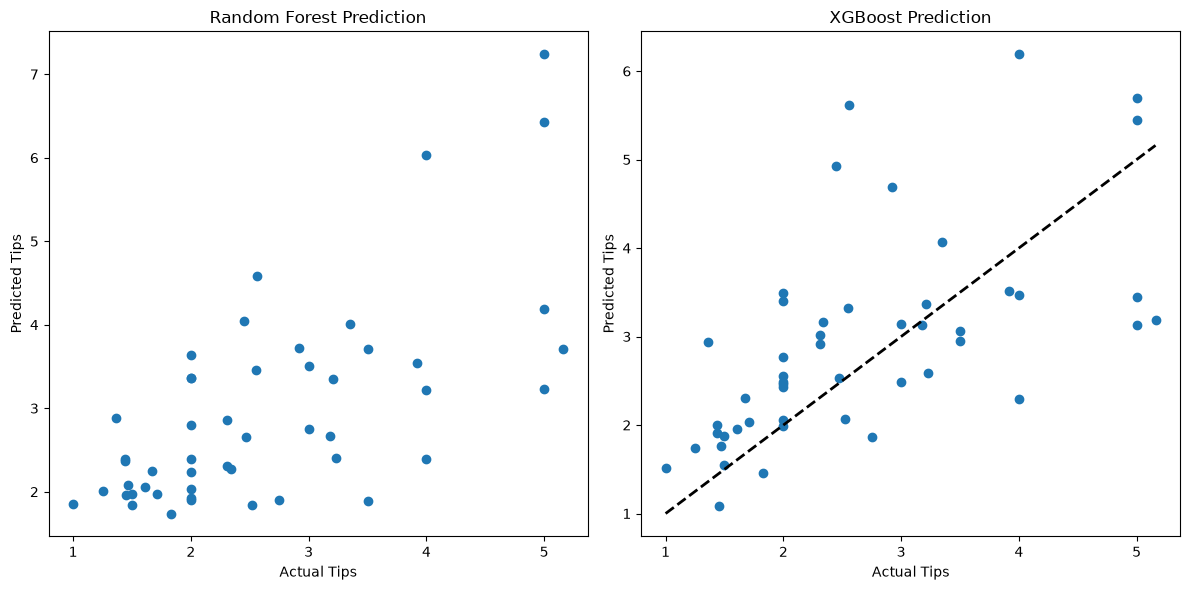

In [ ]:
#prediction with the models
rf_prediction = rf_model.predict(X_test)
xgb_prediction = xgb_model.predict(X_test)

#plotting the prediction results  
import matplotlib.pyplot as plt   #the matplotlib.pyplot module is imported to create visualizations of the model predictions compared to the actual values.
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(y_test, rf_prediction)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Random Forest Prediction")
plt.subplot(1,2,2)
plt.scatter(y_test, xgb_prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("XGBoost Prediction")
plt.tight_layout()
plt.show()

In [90]:
# validate the models based on metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
#random forest metrics
print("Random Forest Metrics:")
print("MAE:",mean_absolute_error(y_test, rf_prediction))
print("MSE:", mean_squared_error(y_test, rf_prediction))
print("R2 Score:", r2_score(y_test, rf_prediction))

#xgboost metrics
print("\nXGBoost Metrics:")
print("MAE:",mean_absolute_error(y_test, xgb_prediction))
print("MSE:", mean_squared_error(y_test, xgb_prediction))
print("R2 Score:", r2_score(y_test, xgb_prediction))

Random Forest Metrics:
MAE: 0.7998102040816328
MSE: 0.9927144814285729
R2 Score: 0.2058102090236993

XGBoost Metrics:
MAE: 0.7804740544727872
MSE: 1.0724530415496694
R2 Score: 0.14201789856581948


In [94]:
# we will move forward with xGBoost
# save the model
import joblib
joblib.dump(xgb_model,'xgb_model.pkl')

['xgb_model.pkl']

In [92]:
# check the prediction from model
X.head()

,total_bill,sex,smoker,day,time
0,16.99,0,0,2,0
1,10.34,1,0,2,0
2,21.01,1,0,2,0
3,23.68,1,0,2,0
4,24.59,0,0,2,0


In [93]:
# predict specific value
xgb_model.predict([[1,0,3,1,4]])

array([1.7308528], dtype=float32)